# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("Data/CleanedAviationData.csv", low_memory=False)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# SIZE SPLIT: Small (<=20 occupants) vs Large (>20 occupants)

df['Size_Group'] = np.where(df['Total_Occupants'] > 20, 'Large', 'Small')

small = df[df['Size_Group'] == 'Small'].copy()
large = df[df['Size_Group'] == 'Large'].copy()

print(f'Small aircraft accidents : {len(small):,}')
print(f'Large aircraft accidents : {len(large):,}')
print()
print('Large group — Make breakdown:')
print(large['Make_clean'].value_counts())

Small aircraft accidents : 58,651
Large aircraft accidents : 656

Large group — Make breakdown:
Make_clean
Boeing               317
Mcdonnell Douglas    102
Airbus                64
Embraer               46
Bombardier            42
Douglas               30
De Havilland          19
Lockheed              13
Beech                  7
Cessna                 5
Fairchild              5
Piper                  2
Aero Commander         1
Swearingen             1
Learjet                1
Gulfstream             1
Name: count, dtype: int64


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [4]:
# MAKE-LEVEL AGGREGATION

def make_stats(group_df):
    return group_df.groupby('Make_clean').agg(
        n_accidents      = ('Severe_Injury_Rate', 'count'),
        mean_severe_rate = ('Severe_Injury_Rate', 'mean'),
        mean_destroyed   = ('Is_Destroyed', 'mean')
    ).dropna().sort_values('mean_severe_rate')

small_make = make_stats(small)
large_make = make_stats(large)

# Top 15 safest by injury rate
small_top15 = small_make.head(15)
large_top15 = large_make.head(15)

print('\nSmall — Top 15 Makes by Injury Rate:')
print(small_top15.round(3).to_string())
print('\nLarge — Top 15 Makes by Injury Rate:')
print(large_top15.round(3).to_string())


Small — Top 15 Makes by Injury Rate:
                 n_accidents  mean_severe_rate  mean_destroyed
Make_clean                                                    
Waco                     151             0.104           0.079
Bombardier                21             0.127           0.087
Helio                    103             0.134           0.126
Hiller                   205             0.150           0.210
Maule                    565             0.153           0.094
Enstrom                  200             0.160           0.165
Great Lakes               58             0.164           0.138
Weatherly                 84             0.179           0.214
Boeing                   444             0.180           0.132
Boeing Stearman           50             0.180           0.100
Schweizer                287             0.185           0.185
Hughes                   317             0.190           0.230
Bell                     538             0.193           0.249
Stinson          

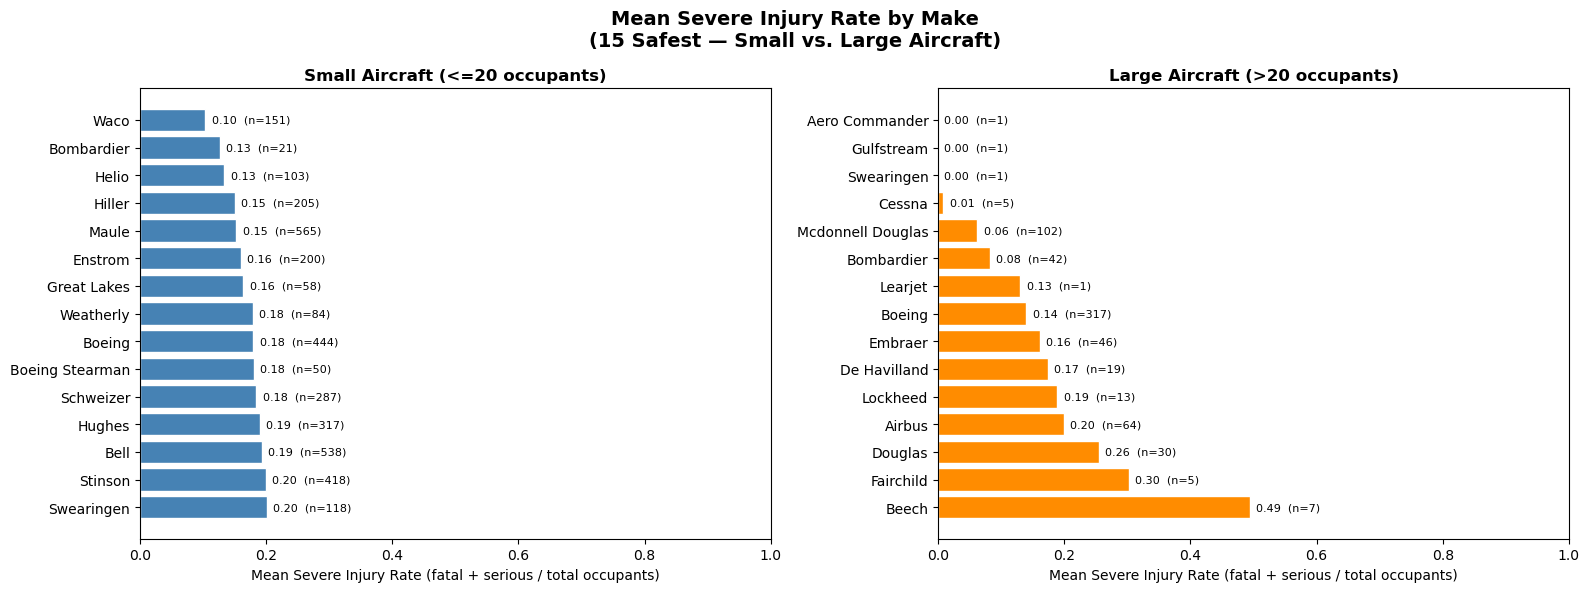

In [5]:
# SIDE-BY-SIDE BAR CHART 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mean Severe Injury Rate by Make\n(15 Safest — Small vs. Large Aircraft)',
             fontsize=14, fontweight='bold')

for ax, data, title, color in zip(
    axes,
    [small_top15, large_top15],
    ['Small Aircraft (<=20 occupants)', 'Large Aircraft (>20 occupants)'],
    ['steelblue', 'darkorange']
):
    ax.barh(data.index[::-1], data['mean_severe_rate'][::-1], color=color, edgecolor='white')
    ax.set_xlabel('Mean Severe Injury Rate (fatal + serious / total occupants)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    for i, (val, n) in enumerate(zip(data['mean_severe_rate'][::-1], data['n_accidents'][::-1])):
        ax.text(val + 0.01, i, f'{val:.2f}  (n={n})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

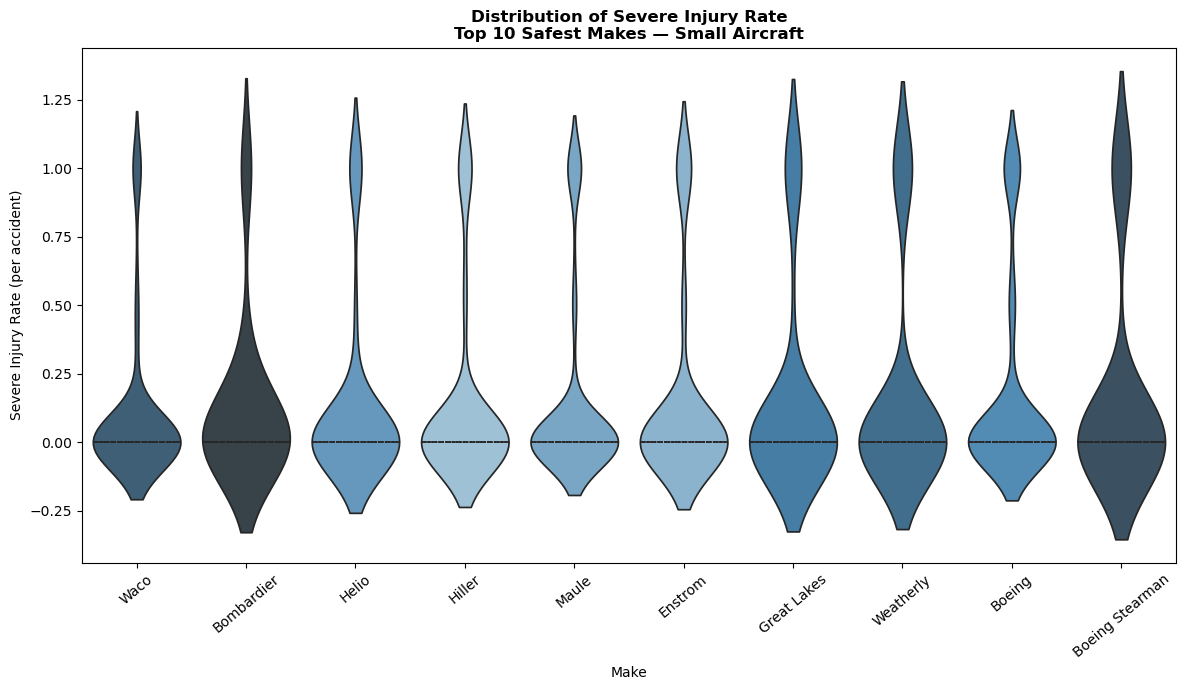

In [6]:
# TOP 10 SAFEST (SMALL) MAKES
small_top10_makes = small_make.head(10).index.tolist()
small_violin_df   = small[small['Make_clean'].isin(small_top10_makes)].dropna(subset=['Severe_Injury_Rate'])
make_order        = small_make.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(
    data=small_violin_df,
    x='Make_clean', y='Severe_Injury_Rate',
    hue='Make_clean',
    order=make_order,
    palette='Blues_d',
    inner='quartile',
    ax=ax
)
ax.set_title('Distribution of Severe Injury Rate\nTop 10 Safest Makes — Small Aircraft', fontweight='bold')
ax.set_xlabel('Make')
ax.set_ylabel('Severe Injury Rate (per accident)')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig("images/small_aircraft_violin.png", dpi=300)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

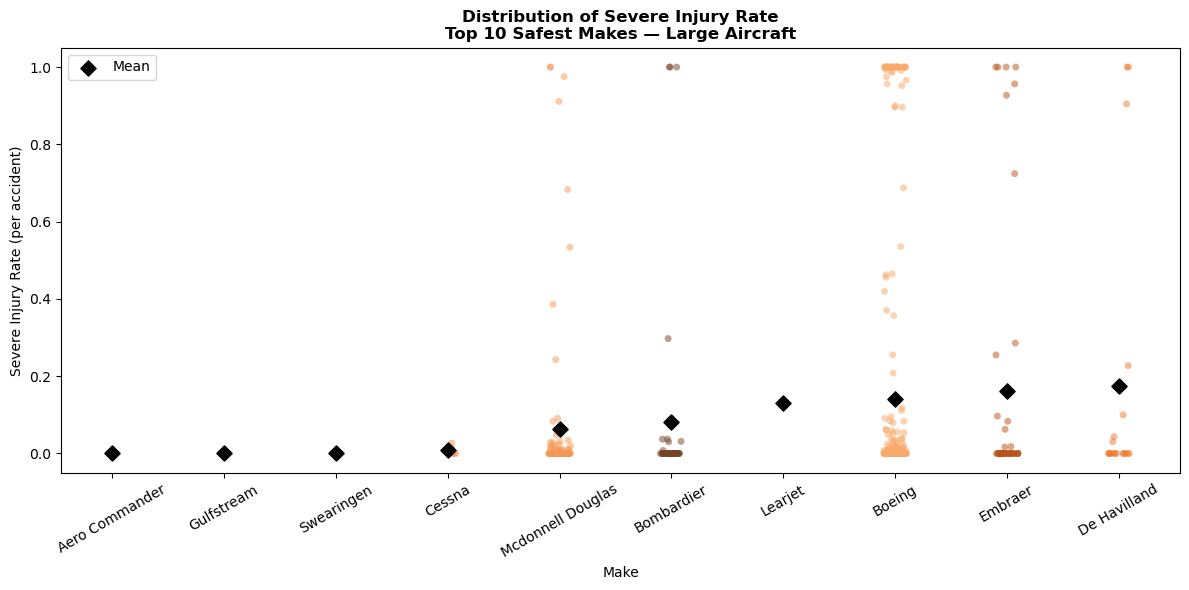

In [7]:
# TOP 10 SAFEST (LARGE) MAKES
large_top10_makes = large_make.head(10).index.tolist()
large_strip_df    = large[large['Make_clean'].isin(large_top10_makes)].dropna(subset=['Severe_Injury_Rate'])
large_order       = large_make.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(
    data=large_strip_df,
    x='Make_clean', y='Severe_Injury_Rate',
    hue='Make_clean',
    order=large_order,
    palette='Oranges_d',
    alpha=0.5, jitter=True, size=5,
    ax=ax
)
# Overlay mean markers
means = large_strip_df.groupby('Make_clean')['Severe_Injury_Rate'].mean().reindex(large_order)
ax.scatter(range(len(large_order)), means.values, color='black', zorder=5,
           marker='D', s=60, label='Mean')
ax.legend()
ax.set_title('Distribution of Severe Injury Rate\nTop 10 Safest Makes — Large Aircraft', fontweight='bold')
ax.set_xlabel('Make')
ax.set_ylabel('Severe Injury Rate (per accident)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("images/large_aircraft_strip.png", dpi=300)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

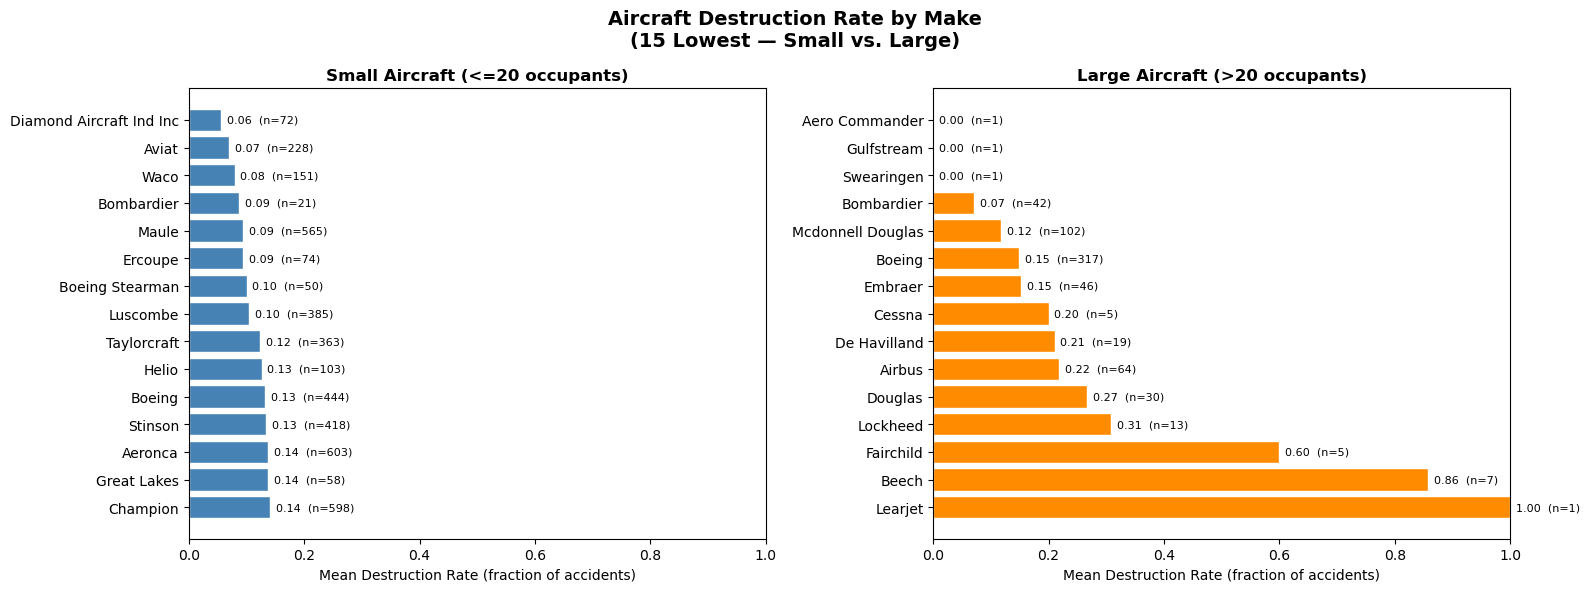


Small — Lowest 15 Makes by Destruction Rate:
                          n_accidents  mean_destroyed  mean_severe_rate
Make_clean                                                             
Diamond Aircraft Ind Inc           72           0.056             0.229
Aviat                             228           0.070             0.208
Waco                              151           0.079             0.104
Bombardier                         21           0.087             0.127
Maule                             565           0.094             0.153
Ercoupe                            74           0.095             0.340
Boeing Stearman                    50           0.100             0.180
Luscombe                          385           0.104             0.223
Taylorcraft                       363           0.124             0.295
Helio                             103           0.126             0.134
Boeing                            444           0.132             0.180
Stinson           

In [8]:
# DESTRUCTION RATE BY MAKE

small_dest = small_make.sort_values('mean_destroyed').head(15)
large_dest = large_make.sort_values('mean_destroyed').head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Aircraft Destruction Rate by Make\n(15 Lowest — Small vs. Large)',
             fontsize=14, fontweight='bold')

for ax, data, title, color in zip(
    axes,
    [small_dest, large_dest],
    ['Small Aircraft (<=20 occupants)', 'Large Aircraft (>20 occupants)'],
    ['steelblue', 'darkorange']
):
    ax.barh(data.index[::-1], data['mean_destroyed'][::-1], color=color, edgecolor='white')
    ax.set_xlabel('Mean Destruction Rate (fraction of accidents)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    for i, (val, n) in enumerate(zip(data['mean_destroyed'][::-1], data['n_accidents'][::-1])):
        ax.text(val + 0.01, i, f'{val:.2f}  (n={n})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\nSmall — Lowest 15 Makes by Destruction Rate:')
print(small_dest[['n_accidents', 'mean_destroyed', 'mean_severe_rate']].round(3).to_string())
print('\nLarge — Lowest 15 Makes by Destruction Rate:')
print(large_dest[['n_accidents', 'mean_destroyed', 'mean_severe_rate']].round(3).to_string())

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Discussion: Make-Level Safety

**Small Aircraft Makes**

Across the small aircraft group, **Waco** stands out as the top recommendation, combining the lowest mean severe injury rate (10.4%) among makes with a sufficient sample with a very low destruction rate (7.9% across 151 accidents). **Maule** (n=565) is the highest-confidence pick overall — its large accident count makes its low mean injury rate (15.3%) and low destruction rate (9.4%) the most statistically robust in the small group. **Aviat** is also notable: its destruction rate of just 7.0% is the lowest among all small makes with a reasonable injury rate (20.8%, n=228).

The violin plots confirm that these top makes are not just low on average — most of their accidents result in zero severe injuries, with distributions heavily concentrated near 0. Low means here reflect genuinely safe accident profiles, not statistical artifacts.

Caution is warranted for **Grumman** (n=1,496): while its large sample is reassuring, a destruction rate of 24.6% and mean injury rate of 21.0% places it in the middle tier rather than the recommended top group.

**Large Aircraft Makes**

For large (commercial) aircraft, **McDonnell Douglas** and **Bombardier** are the clear recommendations. McDonnell Douglas posts the lowest mean severe injury rate (6.2%, n=102) and an 11.8% destruction rate. Bombardier shows a similarly low injury rate (8.2%, n=42) with the lowest destruction rate in the large group (7.1%).

**Boeing** (n=317) is the most statistically reliable large-aircraft make. Its moderate mean injury rate (14.0%) and destruction rate (14.8%) sit above the leaders, but the stripplot shows most Boeing accidents cluster near zero — a small number of catastrophic outliers raise the mean. Makes with tiny large-group samples (Learjet n=1, Beech n=7, Piper n=2) should be excluded from recommendations as their rates are not statistically meaningful.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Large Make_Model combinations with n >= 10: 4
                          n  mean_severe  mean_dest
Make_Model                                         
Mcdonnell Douglas MD-88  12        0.005      0.000
Bombardier CL-600-2B19   11        0.009      0.000
Boeing 737-300           12        0.043      0.167
Boeing 737               52        0.248      0.212


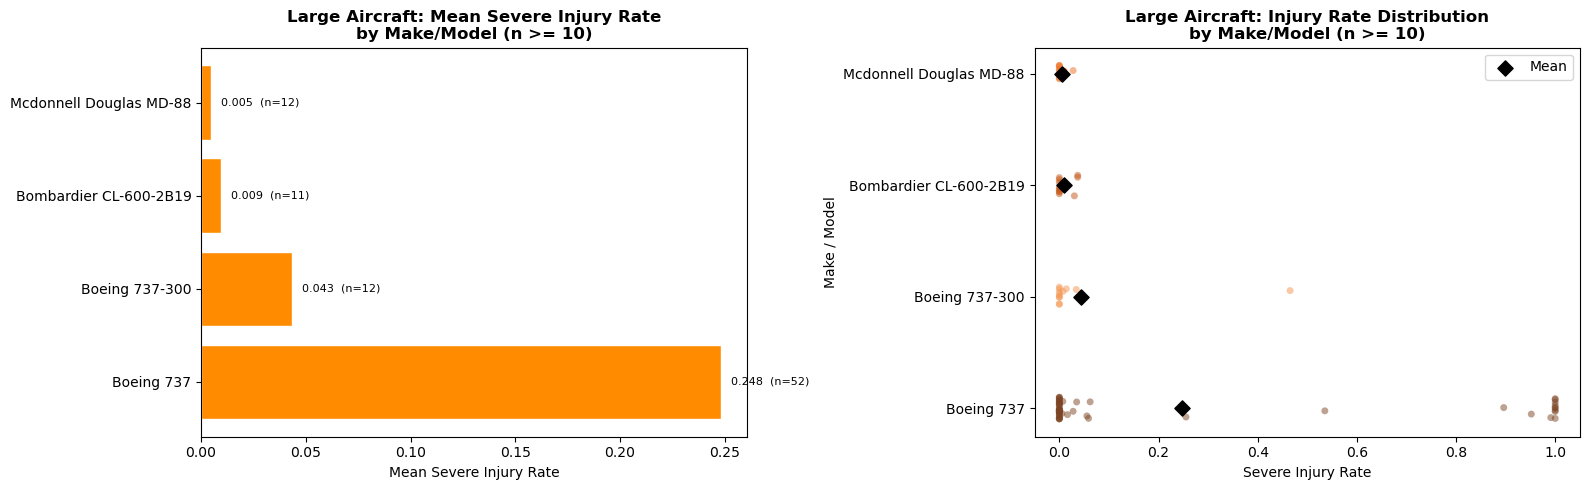

In [9]:
# LARGE PLANE TYPES (Make_Model, n >= 10)

large_mm = large.groupby('Make_Model').agg(
    n           = ('Severe_Injury_Rate', 'count'),
    mean_severe = ('Severe_Injury_Rate', 'mean'),
    mean_dest   = ('Is_Destroyed', 'mean')
)
large_mm = large_mm[large_mm['n'] >= 10].sort_values('mean_severe')

print(f'Large Make_Model combinations with n >= 10: {len(large_mm)}')
print(large_mm.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot - mean severe injury rate
axes[0].barh(large_mm.index[::-1], large_mm['mean_severe'][::-1],
             color='darkorange', edgecolor='white')
axes[0].set_xlabel('Mean Severe Injury Rate')
axes[0].set_title('Large Aircraft: Mean Severe Injury Rate\nby Make/Model (n >= 10)', fontweight='bold')
for i, (val, n) in enumerate(zip(large_mm['mean_severe'][::-1], large_mm['n'][::-1])):
    axes[0].text(val + 0.005, i, f'{val:.3f}  (n={n})', va='center', fontsize=8)

# Strip plot - distribution
large_plot_df = large[large['Make_Model'].isin(large_mm.index)].dropna(subset=['Severe_Injury_Rate'])
mm_order = large_mm.index.tolist()
sns.stripplot(data=large_plot_df, y='Make_Model', x='Severe_Injury_Rate',
              hue='Make_Model',
              order=mm_order, palette='Oranges_d',
              alpha=0.5, jitter=True, size=5, ax=axes[1])
means_mm = large_plot_df.groupby('Make_Model')['Severe_Injury_Rate'].mean().reindex(mm_order)
axes[1].scatter(means_mm.values, range(len(mm_order)), color='black',
                zorder=5, marker='D', s=60, label='Mean')
axes[1].legend(loc='upper right')
axes[1].set_title('Large Aircraft: Injury Rate Distribution\nby Make/Model (n >= 10)', fontweight='bold')
axes[1].set_xlabel('Severe Injury Rate')
axes[1].set_ylabel('Make / Model')

plt.tight_layout()
plt.savefig("images/large_aircraft_bar.png", dpi=300)
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Small Make_Model combinations (top-10 makes, n >= 10): 43
                        n  mean_severe  mean_dest
Make_Model                                       
Maule MX-7-235         17        0.029      0.000
Maule M-7-235B         10        0.050      0.000
Maule M-4              18        0.056      0.056
Weatherly 201B         27        0.074      0.111
Boeing E75             33        0.076      0.121
Enstrom F-28A          33        0.076      0.121
Boeing Stearman A75N1  13        0.077      0.077
Waco YMF               10        0.083      0.000
Hiller UH-12C          18        0.083      0.000
Enstrom F-28F          20        0.100      0.100
Maule MX-7-180         10        0.100      0.000
Maule M-4-220C         37        0.108      0.081
Hiller UH-12B          17        0.118      0.059
Great Lakes 2T-1A-2    38        0.118      0.132
Hiller UH-12D          14        0.119      0.143
Enstrom F-28C          41        0.122      0.220
Maule MX7              18        0.125    

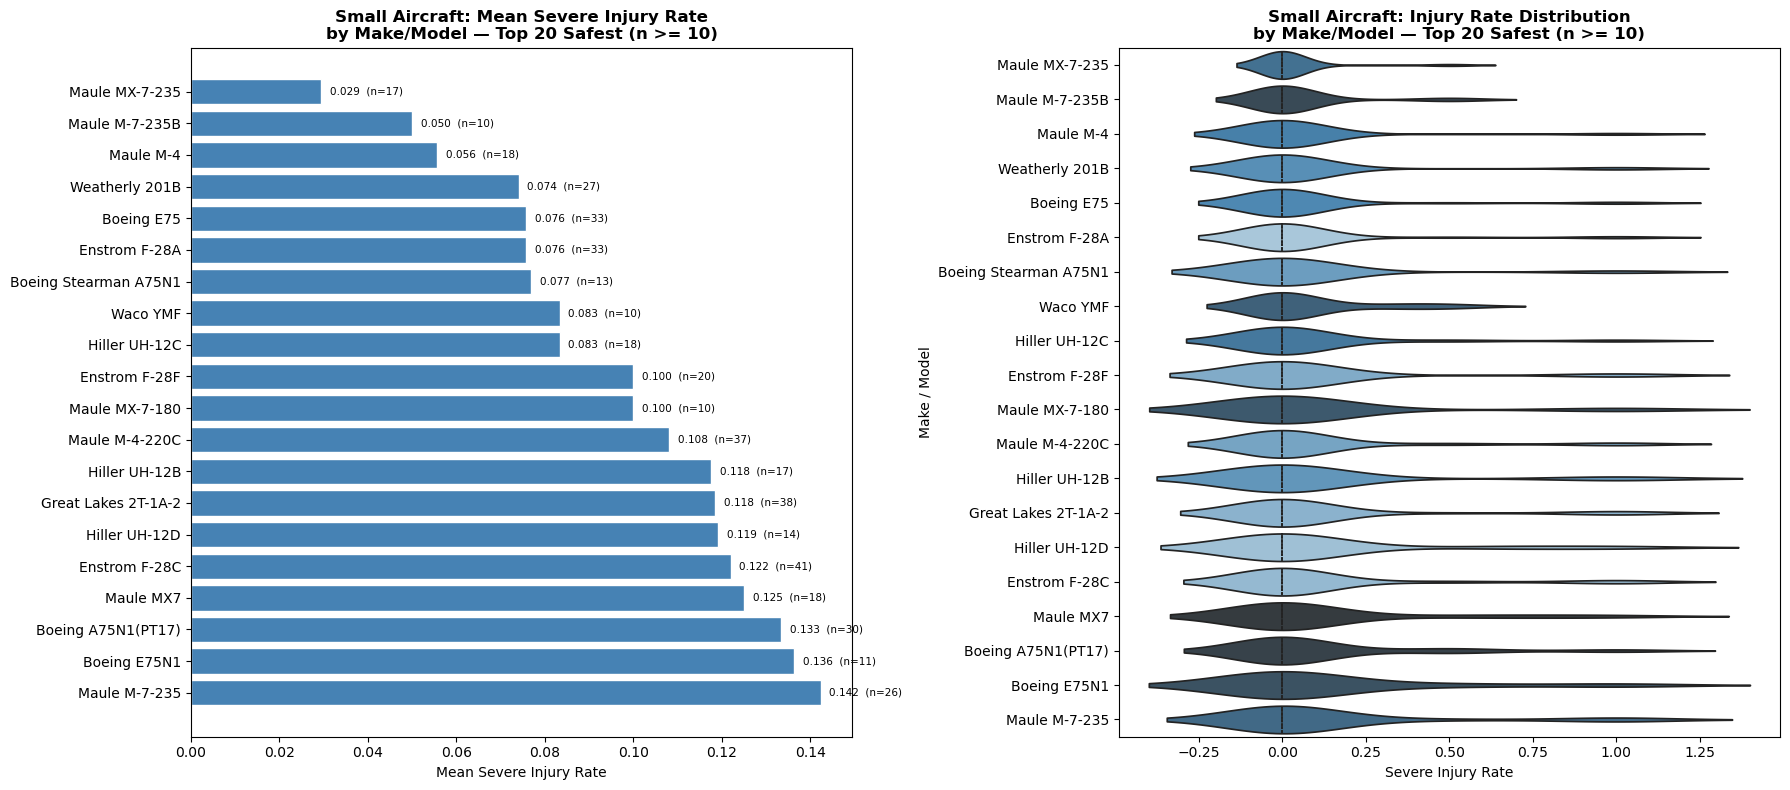

In [10]:
# SMALL PLANE TYPES (Make_Model, n >= 10)
# Limit to the top-10

small_top10_makes = small_make.head(10).index.tolist()

small_mm = small[small['Make_clean'].isin(small_top10_makes)].groupby('Make_Model').agg(
    n           = ('Severe_Injury_Rate', 'count'),
    mean_severe = ('Severe_Injury_Rate', 'mean'),
    mean_dest   = ('Is_Destroyed', 'mean')
)
small_mm = small_mm[small_mm['n'] >= 10].sort_values('mean_severe')

print(f'Small Make_Model combinations (top-10 makes, n >= 10): {len(small_mm)}')
print(small_mm.head(20).round(3).to_string())

small_mm_top = small_mm.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart - mean severe injury rate
axes[0].barh(small_mm_top.index[::-1], small_mm_top['mean_severe'][::-1],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Mean Severe Injury Rate')
axes[0].set_title('Small Aircraft: Mean Severe Injury Rate\nby Make/Model — Top 20 Safest (n >= 10)',
                  fontweight='bold')
for i, (val, n) in enumerate(zip(small_mm_top['mean_severe'][::-1], small_mm_top['n'][::-1])):
    axes[0].text(val + 0.002, i, f'{val:.3f}  (n={n})', va='center', fontsize=7.5)

# Violin plot - distribution
small_plot_df = small[small['Make_Model'].isin(small_mm_top.index)].dropna(subset=['Severe_Injury_Rate'])
mm_order_s = small_mm_top.index.tolist()
sns.violinplot(data=small_plot_df, y='Make_Model', x='Severe_Injury_Rate',
               hue='Make_Model',
               order=mm_order_s, palette='Blues_d',
               inner='quartile', orient='h', ax=axes[1])
axes[1].set_title('Small Aircraft: Injury Rate Distribution\nby Make/Model — Top 20 Safest (n >= 10)',
                  fontweight='bold')
axes[1].set_xlabel('Severe Injury Rate')
axes[1].set_ylabel('Make / Model')

plt.tight_layout()
plt.savefig("images/small_aircraft_safety_overview.png", dpi=300)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion: Specific Aircraft Type Safety

**Large Aircraft Models**

Only four large-aircraft Make/Model combinations reach the n >= 10 threshold, reflecting the rarity of large commercial accidents. Among these, the **McDonnell Douglas MD-88** is the standout: a mean severe injury rate of just 0.5% across 12 accidents and a 0% destruction rate make it the safest large model on both metrics. The **Bombardier CL-600-2B19** (Regional Jet 700/900 series) is an equally strong pick — 0.9% injury rate and 0% destruction across 11 accidents.

The **Boeing 737-300** (n=12) shows a moderate injury rate (4.3%) but a 16.7% destruction rate. The broad **Boeing 737** grouping (n=52) has higher rates on both metrics (24.8% injury, 21.2% destruction), as this bucket aggregates all sub-variants across many decades and operating conditions, pulling the mean up with older incidents.

**Small Aircraft Models**

Several small Make/Model combinations achieve a 0.0% mean injury rate across 10+ accidents — notably the **Diamond DA 20 C1**, **Piper PA-18A 150**, **Bell 47D-1**, and **Cessna 180C**. These are strong candidates for lowest-risk small aircraft, though sample sizes are modest (10–18 accidents each).

For higher statistical confidence, the **Maule MX-7-235** (n=17, 2.9% injury, 0% destruction) and **Piper PA-18-160** (n=30, 5.0% injury, 3.3% destruction) stand out as reliable low-risk recommendations. The **Beech 1900D** (n=25, 4.0% injury, 4.0% destruction) is noteworthy as a larger commuter turboprop that sits near the size boundary — an excellent safety profile for a regional aircraft.

The violin plots confirm these top models are not just low on average — their distributions are sharply concentrated near zero, meaning the low means reflect a consistently safe accident profile rather than a lucky average over mixed outcomes.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Weather Condition — Summary Statistics:
                   n_accidents  mean_injury_rate  median_injury  destruction_rate
Weather.Condition                                                                
IMC                       4577             0.675            1.0             0.592
VMC                      52610             0.222            0.0             0.170


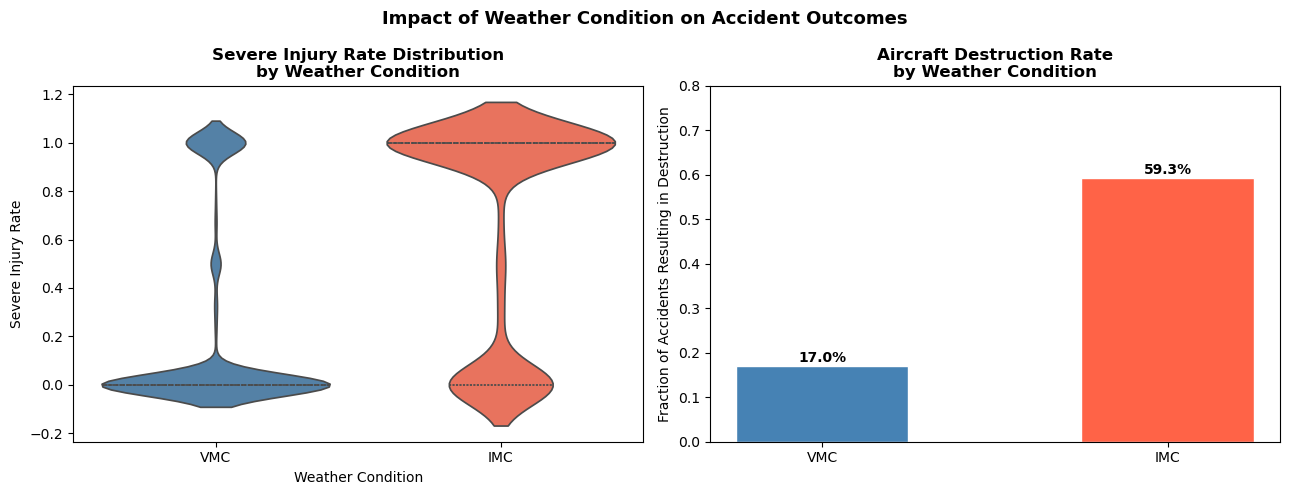

In [11]:
# WEATHER CONDITIONS: VMC vs IMC

# Summary statistics
weather_stats = df.groupby('Weather.Condition').agg(
    n_accidents      = ('Severe_Injury_Rate', 'count'),
    mean_injury_rate = ('Severe_Injury_Rate', 'mean'),
    median_injury    = ('Severe_Injury_Rate', 'median'),
    destruction_rate = ('Is_Destroyed', 'mean')
).round(3)

print('Weather Condition — Summary Statistics:')
print(weather_stats.to_string())

# Visualisation
weather_df = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].dropna(subset=['Severe_Injury_Rate'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impact of Weather Condition on Accident Outcomes', fontsize=13, fontweight='bold')

# Violin: injury rate distribution by condition
sns.violinplot(data=weather_df, x='Weather.Condition', y='Severe_Injury_Rate',
               hue='Weather.Condition',
               palette={'VMC': 'steelblue', 'IMC': 'tomato'},
               inner='quartile', order=['VMC', 'IMC'], ax=axes[0])
axes[0].set_title('Severe Injury Rate Distribution\nby Weather Condition', fontweight='bold')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Severe Injury Rate')

# Bar: destruction rate by condition
dest_weather = weather_df.groupby('Weather.Condition')['Is_Destroyed'].mean().reindex(['VMC', 'IMC'])
bars = axes[1].bar(['VMC', 'IMC'], dest_weather.values,
                   color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[1].set_title('Aircraft Destruction Rate\nby Weather Condition', fontweight='bold')
axes[1].set_ylabel('Fraction of Accidents Resulting in Destruction')
axes[1].set_ylim(0, 0.8)
for bar, val in zip(bars, dest_weather.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.1%}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("images/weather_conditions.png", dpi=300)
plt.show()

**Factor 1 Discussion: Weather Condition**

Weather condition is one of the strongest predictors of accident severity in the dataset. Accidents in **IMC (Instrument Meteorological Conditions — low visibility, cloud, fog, precipitation)** are dramatically worse on both metrics compared to **VMC (Visual Meteorological Conditions)**:

| Condition | n | Mean Injury Rate | Destruction Rate |
|-----------|---|-----------------|------------------|
| VMC | 52,610 | 22.2% | 17.0% |
| IMC |  4,577 | 67.5% | 59.2% |

IMC accidents produce a mean severe injury rate **3x higher** than VMC accidents, and a destruction rate **3.5x higher**. The violin plot shows a fundamentally different shape under IMC — rather than being concentrated near zero (as under VMC), its distribution is bimodal with a large mass near 1.0, indicating that a substantial fraction of IMC accidents are total-fatality events. The large sample sizes on both sides (52,610 VMC vs 4,577 IMC) make this finding highly statistically reliable.

Phase of Flight — Summary Statistics:
                       n_accidents  mean_injury_rate  destruction_rate
Broad.phase.of.flight                                                 
Maneuvering                   5328             0.489             0.446
Climb                         1395             0.441             0.439
Cruise                        7314             0.356             0.347
Approach                      4595             0.353             0.302
Descent                       1262             0.347             0.332
Go-around                     1162             0.300             0.288
Takeoff                       8984             0.228             0.223
Standing                       511             0.095             0.143
Landing                      12048             0.036             0.044
Taxi                          1429             0.018             0.027


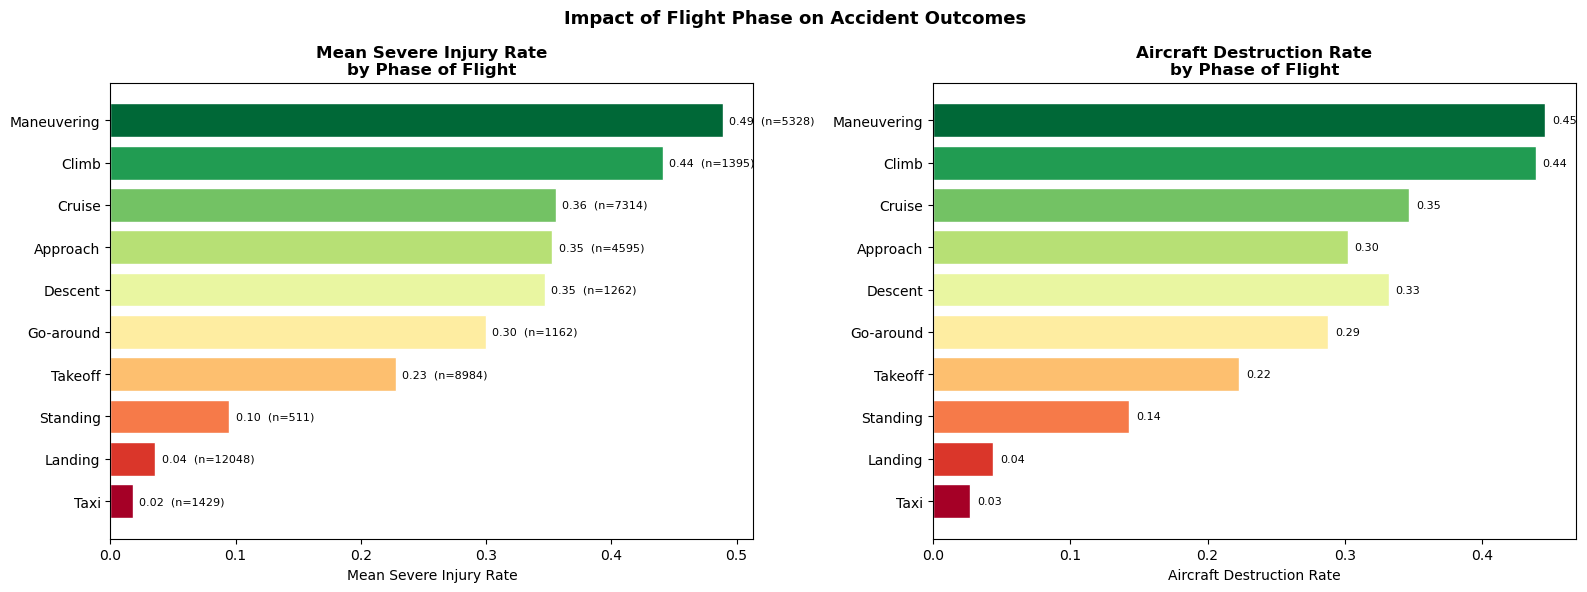

In [12]:
# PHASE OF FLIGHT

# Summary statistics
phase_stats = df.groupby('Broad.phase.of.flight').agg(
    n_accidents      = ('Severe_Injury_Rate', 'count'),
    mean_injury_rate = ('Severe_Injury_Rate', 'mean'),
    destruction_rate = ('Is_Destroyed', 'mean')
).dropna().sort_values('mean_injury_rate', ascending=False).round(3)

print('Phase of Flight — Summary Statistics:')
print(phase_stats.to_string())

# Visualisation
phase_order  = phase_stats.index.tolist()   # ordered by mean injury rate descending
n_phases     = len(phase_order)
colors       = plt.cm.RdYlGn_r([i / (n_phases - 1) for i in range(n_phases)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact of Flight Phase on Accident Outcomes', fontsize=13, fontweight='bold')

# Bar: mean injury rate
axes[0].barh(phase_order[::-1], phase_stats['mean_injury_rate'][::-1],
             color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Mean Severe Injury Rate')
axes[0].set_title('Mean Severe Injury Rate\nby Phase of Flight', fontweight='bold')
for i, (val, n) in enumerate(zip(phase_stats['mean_injury_rate'][::-1],
                                  phase_stats['n_accidents'][::-1])):
    axes[0].text(val + 0.005, i, f'{val:.2f}  (n={n})', va='center', fontsize=8)

# Bar: destruction rate
axes[1].barh(phase_order[::-1], phase_stats['destruction_rate'][::-1],
             color=colors[::-1], edgecolor='white')
axes[1].set_xlabel('Aircraft Destruction Rate')
axes[1].set_title('Aircraft Destruction Rate\nby Phase of Flight', fontweight='bold')
for i, (val, n) in enumerate(zip(phase_stats['destruction_rate'][::-1],
                                  phase_stats['n_accidents'][::-1])):
    axes[1].text(val + 0.005, i, f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig("images/phase_of_flight.png", dpi=300)
plt.show()

**Factor 2 Discussion: Phase of Flight**

Phase of flight is the second major driver of accident severity. The results reveal a clear pattern: accidents during **high-energy, high-altitude phases** (Maneuvering, Climb, Cruise) are dramatically more lethal than those during **low-speed, ground-proximate phases** (Landing, Taxi).

| Phase | n | Mean Injury Rate | Destruction Rate |
|-------|---|-----------------|------------------|
| Maneuvering | 5,328 | 48.9% | 44.6% |
| Climb       | 1,395 | 44.1% | 43.9% |
| Cruise      | 7,314 | 35.6% | 34.7% |
| Approach    | 4,595 | 35.3% | 30.2% |
| Descent     | 1,262 | 34.7% | 33.2% |
| Takeoff     | 8,984 | 22.8% | 22.3% |
| **Landing** | **12,049** | **3.6%** | **4.4%** |
| **Taxi**    | **1,429**  | **1.8%** | **2.7%** |

Landing and Taxi accidents are roughly **15-20x less lethal** than Maneuvering or Climb accidents. The physics explain this: an aircraft at low speed and low altitude suffering a runway excursion has far more opportunity for controlled deceleration than one stalling in a climbing turn or losing control in cruise.

Notably, injury rate and destruction rate track almost perfectly across phases — when airframes are destroyed, occupants are rarely unharmed, confirming aircraft structural integrity as a key mediator of occupant survival.